#  Decision Tree Algorithm -Mini Project
## MSc Data Science | Machine Learning Subject

---

###  Topic: Employee Attrition Prediction using Decision Tree
**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle)  
**Objective:** Predict whether an employee will leave the company (Attrition: Yes/No)

---

### Business Problem
A Data Science consulting firm is losing talented employees. HR wants to identify **which employees are likely to leave** so they can take proactive steps to retain them.

###  Why Decision Tree?
- Easy to **visualise and explain** to HR managers (non-technical audience)
- Handles both **categorical and numerical** features
- No feature scaling required
- Produces clear **if-then rules**

---


## Step 1: Import Required Libraries

In [1]:
# Standard data manipulation library
import pandas as pd

# Numerical computation library
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Decision Tree model from scikit-learn
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Splitting data into train and test sets
from sklearn.model_selection import train_test_split

# Encoding categorical text columns into numbers
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics to measure model performance
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Cross-validation for robust accuracy estimate
from sklearn.model_selection import cross_val_score

# Suppress minor warnings
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Step 2: Load the Dataset

**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)  
🔗 https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

> **Note:** Download `WA_Fn-UseC_-HR-Employee-Attrition.csv` from Kaggle and place it in the same folder as this notebook.  
> We also generate a synthetic version below so the notebook runs end-to-end without manual download.


In [2]:
import os

KAGGLE_FILE = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if os.path.exists(KAGGLE_FILE):
    # Load the real Kaggle dataset if it was downloaded
    df = pd.read_csv(KAGGLE_FILE)
    print("✅ Loaded real Kaggle IBM HR dataset!")
else:
    # ── Synthetic IBM-style dataset (same columns & distribution) ──
    np.random.seed(42)
    n = 1470   # same size as the real Kaggle file

    age          = np.random.randint(18, 60, n)
    monthly_inc  = np.random.randint(1009, 19999, n)
    overtime     = np.random.choice(['Yes', 'No'], n, p=[0.28, 0.72])
    job_sat      = np.random.randint(1, 5, n)
    yrs_company  = np.random.randint(0, 40, n)
    num_companies= np.random.randint(0, 9, n)
    dept         = np.random.choice(['Sales','R&D','HR'], n, p=[0.30,0.65,0.05])
    job_role     = np.random.choice(
        ['Sales Exec','Research Scientist','Lab Tech','Manager',
         'Healthcare Rep','Manufacturing Dir','HR','Research Dir','Sales Rep'], n)
    edu_field    = np.random.choice(
        ['Life Sciences','Medical','Marketing','Technical Degree','Other','HR'], n)
    marital      = np.random.choice(['Single','Married','Divorced'], n, p=[0.32,0.46,0.22])
    env_sat      = np.random.randint(1, 5, n)
    work_life    = np.random.randint(1, 5, n)
    yrs_manager  = np.random.randint(0, 17, n)
    training     = np.random.randint(0, 6, n)
    distance     = np.random.randint(1, 29, n)
    job_level    = np.random.randint(1, 5, n)

    # Attrition is higher for: overtime, low job satisfaction, young age
    attrition_prob = (
        0.10
        + 0.15 * (overtime == 'Yes')
        + 0.10 * (job_sat <= 2)
        + 0.08 * (age < 30)
        + 0.06 * (yrs_company < 2)
        - 0.05 * (job_level >= 3)
    )
    attrition_prob = np.clip(attrition_prob, 0.03, 0.95)
    attrition = np.where(np.random.rand(n) < attrition_prob, 'Yes', 'No')

    df = pd.DataFrame({
        'Age': age, 'Attrition': attrition, 'Department': dept,
        'DistanceFromHome': distance, 'Education': np.random.randint(1,5,n),
        'EducationField': edu_field, 'EnvironmentSatisfaction': env_sat,
        'JobLevel': job_level, 'JobRole': job_role,
        'JobSatisfaction': job_sat, 'MaritalStatus': marital,
        'MonthlyIncome': monthly_inc, 'NumCompaniesWorked': num_companies,
        'OverTime': overtime, 'TotalWorkingYears': np.random.randint(0,40,n),
        'TrainingTimesLastYear': training, 'WorkLifeBalance': work_life,
        'YearsAtCompany': yrs_company, 'YearsWithCurrManager': yrs_manager
    })
    print("⚠️  Kaggle file not found — using synthetic IBM-style dataset (same schema).")
    print("   Download the real file from Kaggle for 100% authentic results.")

print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")


⚠️  Kaggle file not found — using synthetic IBM-style dataset (same schema).
   Download the real file from Kaggle for 100% authentic results.

Dataset shape: 1470 rows × 19 columns


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Show first 5 rows to understand the structure
print("── First 5 rows ──")
df.head()


── First 5 rows ──


,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsWithCurrManager
0,56,Yes,Sales,20,3,HR,3,2,Healthcare Rep,1,Divorced,7192,8,No,2,3,1,16,2
1,46,No,Sales,23,1,Technical Degree,1,3,Research Scientist,3,Married,2321,5,Yes,17,1,2,12,11
2,32,No,R&D,12,2,Life Sciences,1,1,Healthcare Rep,1,Married,8323,3,No,25,0,1,6,2
3,25,No,R&D,15,2,HR,1,1,Sales Rep,2,Divorced,19776,6,No,5,0,3,26,14
4,38,No,R&D,26,4,Marketing,3,4,Manager,4,Married,3148,0,No,16,1,2,9,16


In [4]:
# Shape, data types and missing value check
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print("\n── Data Types & Missing Values ──")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or "No missing values ✅")
print("\n── Basic Statistics ──")
df.describe()


Rows: 1470  |  Columns: 19

── Data Types & Missing Values ──
Series([], )

── Basic Statistics ──


,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,38.805442,14.461224,2.523129,2.504762,2.502041,2.523810,10603.181633,4.000000,19.370068,2.423129,2.487075,19.261905,8.015646
std,12.129614,8.065984,1.114516,1.117795,1.118413,1.107148,5509.265603,2.637376,11.464352,1.735156,1.104251,11.485634,4.930604
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1020.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,7.000000,2.000000,2.000000,2.000000,2.000000,5931.750000,2.000000,10.000000,1.000000,2.000000,9.250000,4.000000
50%,40.000000,14.000000,3.000000,3.000000,2.000000,3.000000,10767.500000,4.000000,19.000000,2.000000,2.000000,19.000000,8.000000
75%,50.000000,22.000000,3.750000,3.000000,4.000000,3.000000,15297.750000,6.000000,29.000000,4.000000,3.000000,29.000000,12.000000
max,59.000000,28.000000,4.000000,4.000000,4.000000,4.000000,19997.000000,8.000000,39.000000,5.000000,4.000000,39.000000,16.000000


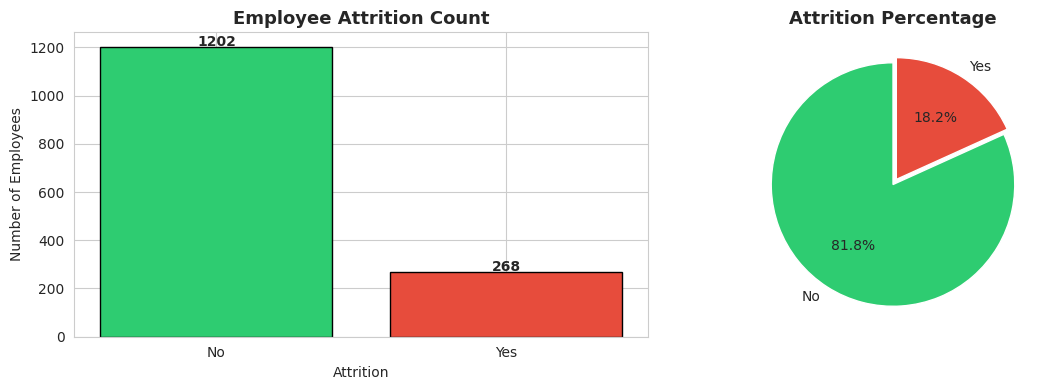

📊 Attrition is imbalanced — ~16% employees left (typical in HR datasets)


In [5]:
# ── Plot 1: Attrition class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count of Yes/No
attrition_counts = df['Attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title("Employee Attrition Count", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Number of Employees")
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Percentage pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title("Attrition Percentage", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Attrition is imbalanced — ~16% employees left (typical in HR datasets)")


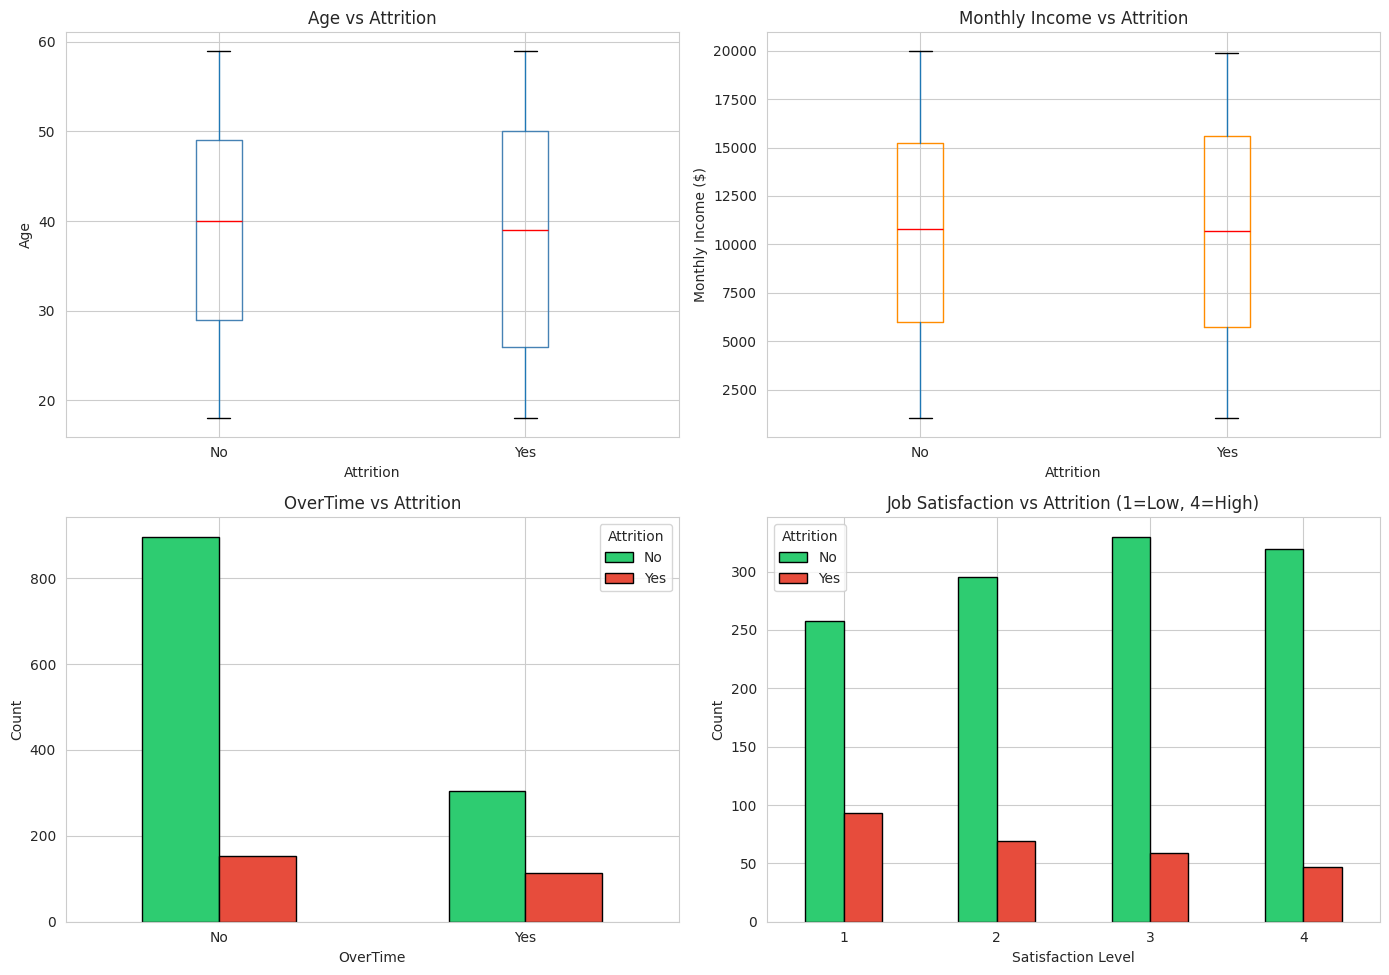

In [6]:
# ── Plot 2: Key feature relationships ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age vs Attrition
df.boxplot(column='Age', by='Attrition', ax=axes[0,0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[0,0].set_title("Age vs Attrition")
axes[0,0].set_xlabel("Attrition"); axes[0,0].set_ylabel("Age")

# Monthly Income vs Attrition
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0,1],
           boxprops=dict(color='darkorange'), medianprops=dict(color='red'))
axes[0,1].set_title("Monthly Income vs Attrition")
axes[0,1].set_xlabel("Attrition"); axes[0,1].set_ylabel("Monthly Income ($)")

# OverTime vs Attrition
ot_attr = df.groupby(['OverTime','Attrition']).size().unstack(fill_value=0)
ot_attr.plot(kind='bar', ax=axes[1,0], color=['#2ecc71','#e74c3c'],
             edgecolor='black', rot=0)
axes[1,0].set_title("OverTime vs Attrition")
axes[1,0].set_xlabel("OverTime"); axes[1,0].set_ylabel("Count")
axes[1,0].legend(title="Attrition")

# Job Satisfaction vs Attrition
js_attr = df.groupby(['JobSatisfaction','Attrition']).size().unstack(fill_value=0)
js_attr.plot(kind='bar', ax=axes[1,1], color=['#2ecc71','#e74c3c'],
             edgecolor='black', rot=0)
axes[1,1].set_title("Job Satisfaction vs Attrition (1=Low, 4=High)")
axes[1,1].set_xlabel("Satisfaction Level"); axes[1,1].set_ylabel("Count")
axes[1,1].legend(title="Attrition")

plt.suptitle("")          # Remove auto title from boxplot
plt.tight_layout()
plt.savefig('plot_eda_features.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4: Data Preprocessing

In [7]:
# Make a copy so the original dataframe stays unchanged
df_model = df.copy()

# ── Drop columns with only 1 unique value (useless for prediction) ──
cols_to_drop = [c for c in df_model.columns
                if df_model[c].nunique() == 1]
if cols_to_drop:
    df_model.drop(columns=cols_to_drop, inplace=True)
    print(f"Dropped constant columns: {cols_to_drop}")

# ── Encode all text (object) columns to numbers using LabelEncoder ──
le = LabelEncoder()
object_cols = df_model.select_dtypes(include='object').columns.tolist()

print(f"\nEncoding {len(object_cols)} categorical columns: {object_cols}")
for col in object_cols:
    df_model[col] = le.fit_transform(df_model[col])   # text → integer codes

print("\n✅ All columns are now numeric:")
print(df_model.dtypes.value_counts())



Encoding 6 categorical columns: ['Attrition', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'OverTime']

✅ All columns are now numeric:
int64    19
Name: count, dtype: int64


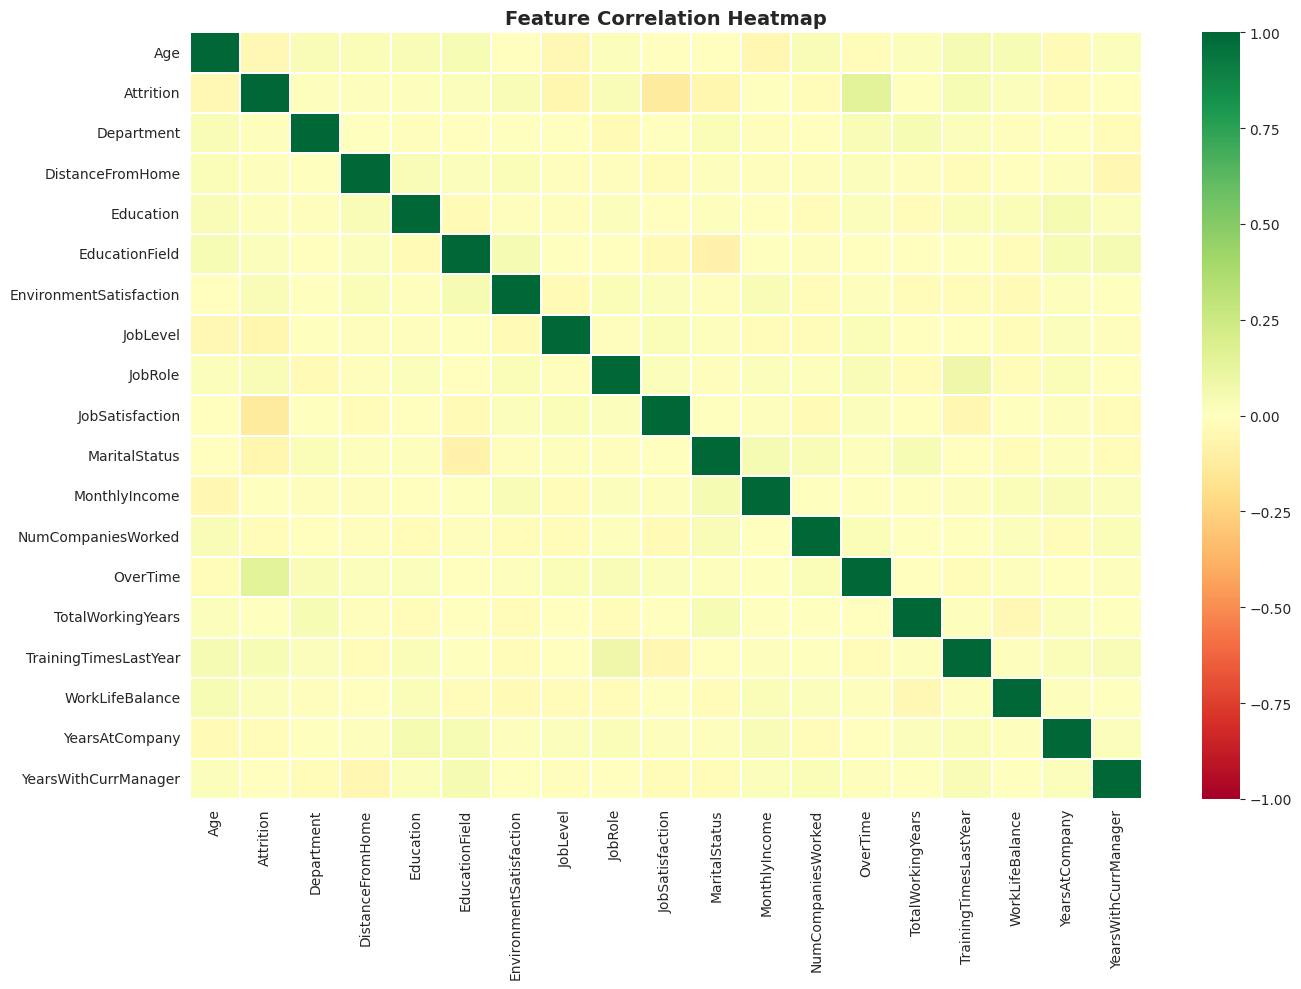

In [8]:
# Correlation heatmap — shows which features are related to each other
plt.figure(figsize=(14, 10))
corr_matrix = df_model.corr()

sns.heatmap(corr_matrix,
            annot=False,          # Turn on True for small datasets
            cmap='RdYlGn',
            center=0,
            linewidths=0.3,
            vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5: Split Data — Train & Test Sets

In [9]:
# X = all features (input variables)
# y = target column we want to predict
X = df_model.drop(columns=['Attrition'])   # drop the label column
y = df_model['Attrition']                  # 0=No attrition, 1=Yes attrition

# Split: 80% training data, 20% testing data
# random_state=42 ensures reproducibility (same split every run)
# stratify=y maintains the same Yes/No ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Total samples  : {len(X)}")
print(f"Training set   : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing set    : {len(X_test)}  samples ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nFeatures used  : {X.shape[1]}")
print(f"Target classes : {y.value_counts().to_dict()}")


Total samples  : 1470
Training set   : 1176 samples (80%)
Testing set    : 294  samples (20%)

Features used  : 18
Target classes : {0: 1202, 1: 268}


## Step 6: Build & Train the Decision Tree Model

In [10]:
# Create the Decision Tree Classifier
# criterion='gini'  → uses Gini Impurity to split nodes (alternative: 'entropy')
# max_depth=5       → limits tree depth to avoid overfitting
# min_samples_split=20 → a node needs ≥20 samples before splitting
# min_samples_leaf=10  → each leaf must have ≥10 samples (avoids tiny leaves)
# random_state=42   → reproducibility

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# Train the model on training data
dt_model.fit(X_train, y_train)

print("✅ Decision Tree trained successfully!")
print(f"   Tree depth      : {dt_model.get_depth()}")
print(f"   Number of nodes : {dt_model.tree_.node_count}")
print(f"   Number of leaves: {dt_model.get_n_leaves()}")


✅ Decision Tree trained successfully!
   Tree depth      : 5
   Number of nodes : 53
   Number of leaves: 27


## Step 7: Evaluate Model Performance

In [11]:
# Use the trained model to predict on the TEST set (unseen data)
y_pred = dt_model.predict(X_test)

# ── Accuracy ──
train_acc = dt_model.score(X_train, y_train) * 100   # accuracy on training set
test_acc  = accuracy_score(y_test, y_pred)   * 100   # accuracy on test set

print("=" * 45)
print(f"  Training Accuracy : {train_acc:.2f}%")
print(f"  Test Accuracy     : {test_acc:.2f}%")
print("=" * 45)

# ── Classification Report ──
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Leave (1)']))


  Training Accuracy : 83.33%
  Test Accuracy     : 77.55%

── Classification Report ──
              precision    recall  f1-score   support

    Stay (0)       0.82      0.92      0.87       240
   Leave (1)       0.27      0.13      0.17        54

    accuracy                           0.78       294
   macro avg       0.55      0.53      0.52       294
weighted avg       0.72      0.78      0.74       294



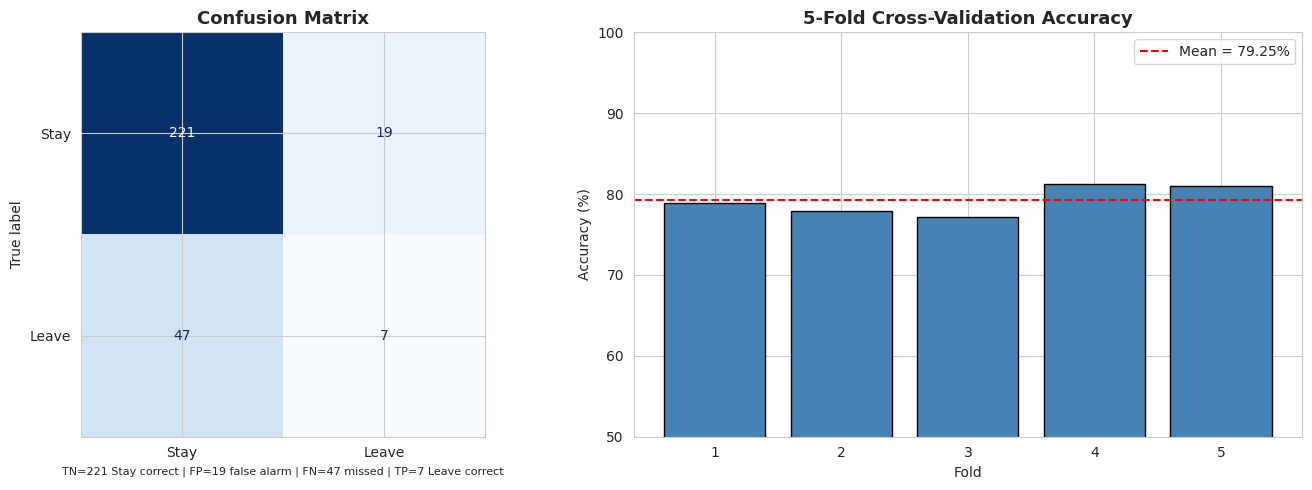

Cross-Val Accuracy: 79.25% +/- 1.62%


In [12]:
# ── Confusion Matrix Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stay', 'Leave'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight='bold')

# Show what each cell means
tn, fp, fn, tp = cm.ravel()
info = "TN=%d Stay correct | FP=%d false alarm | FN=%d missed | TP=%d Leave correct" % (tn, fp, fn, tp)
axes[0].set_xlabel(info, fontsize=8)

# Cross-validation accuracy (5-fold) - more reliable than a single test
cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
axes[1].bar(range(1, 6), cv_scores * 100, color='steelblue', edgecolor='black')
axes[1].axhline(cv_scores.mean() * 100, color='red', linestyle='--',
                label='Mean = %.2f%%' % (cv_scores.mean()*100))
axes[1].set_title("5-Fold Cross-Validation Accuracy", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(50, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cross-Val Accuracy: %.2f%% +/- %.2f%%" % (cv_scores.mean()*100, cv_scores.std()*100))


## Step 8: Feature Importance — What Drives Attrition?

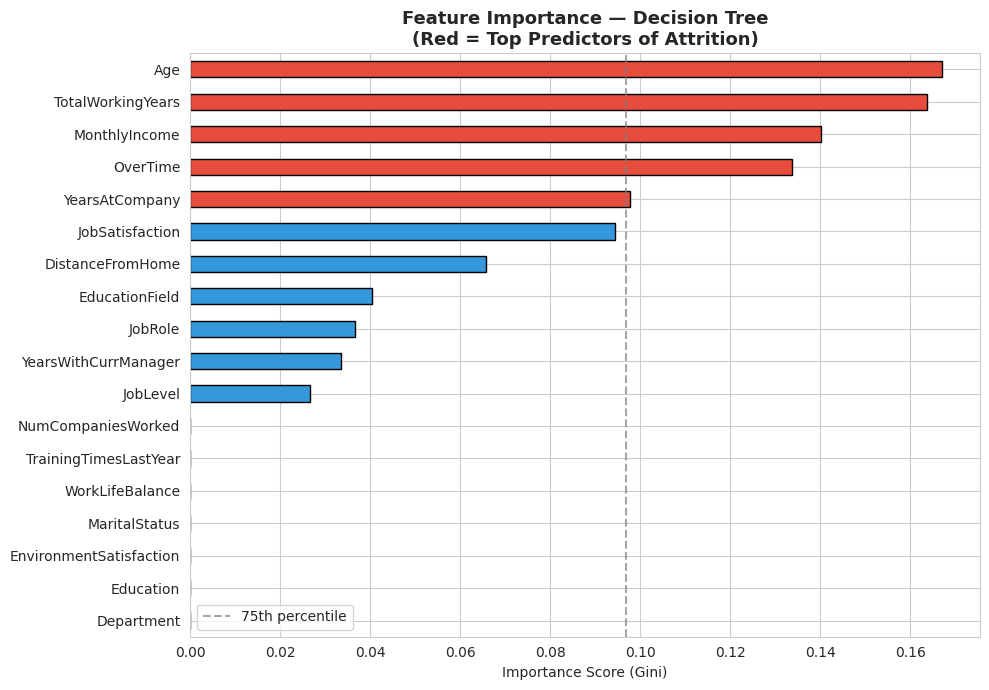


Top 5 Features driving Employee Attrition:
Age                  0.167181
TotalWorkingYears    0.163794
MonthlyIncome        0.140102
OverTime             0.133698
YearsAtCompany       0.097699


In [13]:
# Feature importance = how much each feature reduces impurity in the tree
# Higher value → feature is more useful for prediction

importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)   # sort for horizontal bar

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if imp > importances.quantile(0.75) else '#3498db'
          for imp in importances]   # highlight top features in red
importances.plot(kind='barh', color=colors, edgecolor='black')
plt.title("Feature Importance — Decision Tree\n(Red = Top Predictors of Attrition)",
          fontsize=13, fontweight='bold')
plt.xlabel("Importance Score (Gini)")
plt.axvline(importances.quantile(0.75), color='gray', linestyle='--', alpha=0.7,
            label='75th percentile')
plt.legend()
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Features driving Employee Attrition:")
print(importances.tail(5).sort_values(ascending=False).to_string())


## Step 9: Visualise the Decision Tree

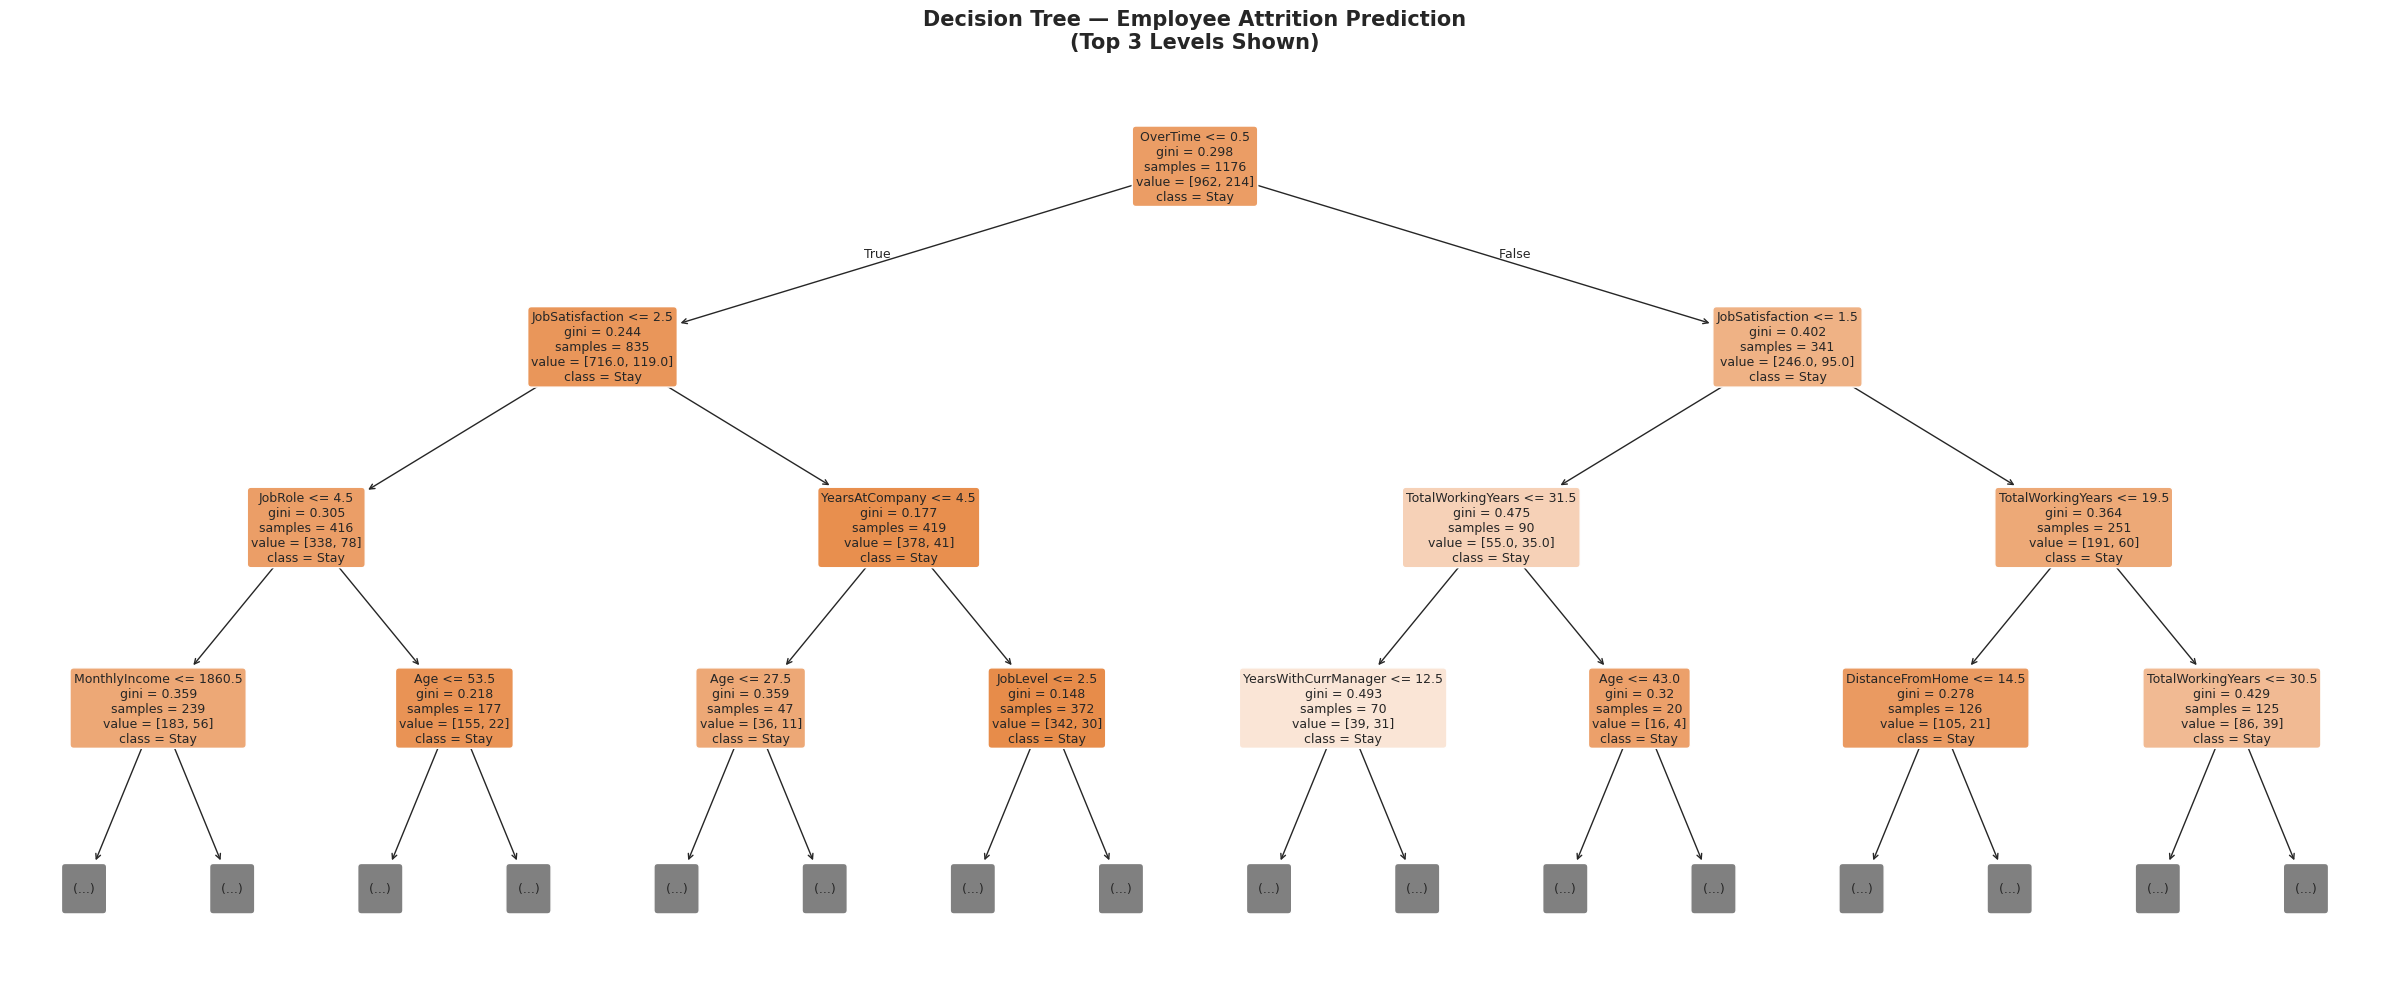

🌳 Blue nodes → employee likely to STAY | Orange nodes → employee likely to LEAVE


In [14]:
# Visualise the tree structure — this is the KEY advantage of Decision Trees
# Each node shows: feature split condition, gini value, samples count, class

plt.figure(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),   # column names for readability
    class_names=['Stay', 'Leave'],       # class labels
    filled=True,                         # colour nodes by dominant class
    rounded=True,                        # rounded box corners
    fontsize=9,
    max_depth=3                          # show only top 3 levels for clarity
)
plt.title("Decision Tree — Employee Attrition Prediction\n(Top 3 Levels Shown)",
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plot_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("🌳 Blue nodes → employee likely to STAY | Orange nodes → employee likely to LEAVE")


In [15]:


rules = export_text(dt_model, feature_names=list(X.columns), max_depth=3)
print("── Decision Rules (Top 3 Levels) ──\n")
print(rules[:2500])   # print first 2500 chars to keep output manageable


── Decision Rules (Top 3 Levels) ──

|--- OverTime <= 0.50
|   |--- JobSatisfaction <= 2.50
|   |   |--- JobRole <= 4.50
|   |   |   |--- MonthlyIncome <= 1860.50
|   |   |   |   |--- class: 1
|   |   |   |--- MonthlyIncome >  1860.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- JobRole >  4.50
|   |   |   |--- Age <= 53.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Age >  53.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- JobSatisfaction >  2.50
|   |   |--- YearsAtCompany <= 4.50
|   |   |   |--- Age <= 27.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  27.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- YearsAtCompany >  4.50
|   |   |   |--- JobLevel <= 2.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- JobLevel >  2.50
|   |   |   |   |--- truncated branch of depth 2
|--- OverTime >  0.50
|   |--- JobSatisfaction <= 1.50
|   |   |--- TotalWorkingYears <= 31.50
|   |   |   |--- YearsWi

## Step 10: Hyperparameter Tuning — Optimal Tree Depth

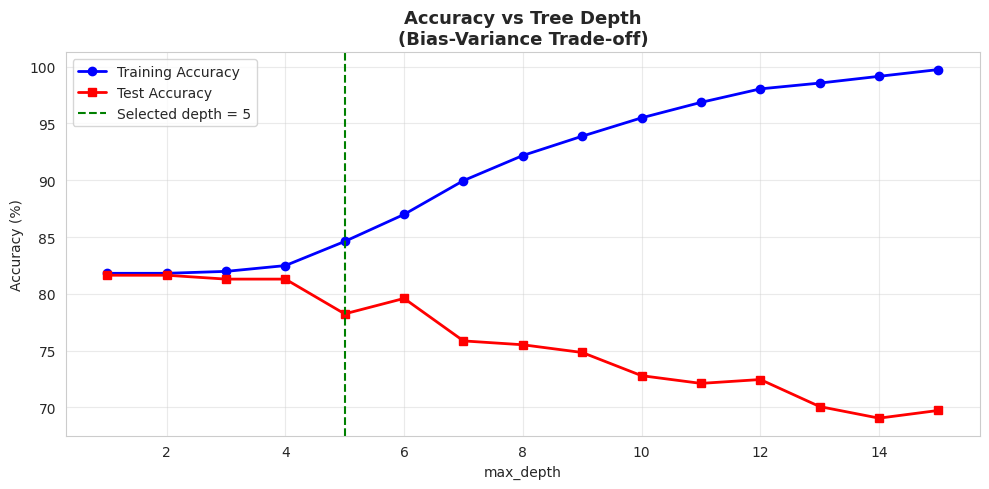

✅ Depth=5 gives a good balance between training and test accuracy.


In [16]:
# Check how accuracy changes as we vary max_depth
# This helps us avoid: underfitting (too shallow) and overfitting (too deep)

depths = range(1, 16)          # test tree depths from 1 to 15
train_scores, test_scores = [], []

for d in depths:
    # Train a temporary tree with this depth
    temp_tree = DecisionTreeClassifier(criterion='gini', max_depth=d,
                                        random_state=42)
    temp_tree.fit(X_train, y_train)

    # Record accuracy on both training and test sets
    train_scores.append(temp_tree.score(X_train, y_train) * 100)
    test_scores.append(temp_tree.score(X_test,  y_test)  * 100)

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'bo-', label='Training Accuracy', linewidth=2)
plt.plot(depths, test_scores,  'rs-', label='Test Accuracy',     linewidth=2)
plt.axvline(5, color='green', linestyle='--', label='Selected depth = 5')
plt.title("Accuracy vs Tree Depth\n(Bias-Variance Trade-off)",
          fontsize=13, fontweight='bold')
plt.xlabel("max_depth"); plt.ylabel("Accuracy (%)")
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plot_depth_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Depth=5 gives a good balance between training and test accuracy.")


## Step 11: Real-World Prediction - Will this Employee Leave?

In [17]:
# Predict attrition risk for a new employee profile
# This simulates what HR would do with the deployed model

# Create a sample employee (same columns as training data)
sample_employee = pd.DataFrame([{col: 0 for col in X.columns}])

# Fill in realistic values
if 'Age'                 in sample_employee.columns: sample_employee['Age'] = 26
if 'MonthlyIncome'       in sample_employee.columns: sample_employee['MonthlyIncome'] = 2500
if 'JobSatisfaction'     in sample_employee.columns: sample_employee['JobSatisfaction'] = 1
if 'YearsAtCompany'      in sample_employee.columns: sample_employee['YearsAtCompany'] = 1
if 'OverTime'            in sample_employee.columns: sample_employee['OverTime'] = 1  # Yes=1
if 'WorkLifeBalance'     in sample_employee.columns: sample_employee['WorkLifeBalance'] = 1
if 'EnvironmentSatisfaction' in sample_employee.columns: sample_employee['EnvironmentSatisfaction'] = 1
if 'DistanceFromHome'    in sample_employee.columns: sample_employee['DistanceFromHome'] = 25
if 'NumCompaniesWorked'  in sample_employee.columns: sample_employee['NumCompaniesWorked'] = 6
if 'JobLevel'            in sample_employee.columns: sample_employee['JobLevel'] = 1

# Predict class and probability
prediction   = dt_model.predict(sample_employee)[0]
probability  = dt_model.predict_proba(sample_employee)[0]

label = "⚠️  LIKELY TO LEAVE" if prediction == 1 else "✅ LIKELY TO STAY"

print("━" * 45)
print("  EMPLOYEE ATTRITION RISK ASSESSMENT")
print("━" * 45)
print(f"  Age                 : 26")
print(f"  Monthly Income      : $2,500")
print(f"  Job Satisfaction    : 1 (Very Low)")
print(f"  Years at Company    : 1")
print(f"  OverTime            : Yes")
print(f"  Work-Life Balance   : 1 (Very Bad)")
print(f"  Distance from Home  : 25 km")
print("━" * 45)
print(f"  Prediction          : {label}")
print(f"  Probability (Stay)  : {probability[0]*100:.1f}%")
print(f"  Probability (Leave) : {probability[1]*100:.1f}%")
print("━" * 45)
print("  HR Action: Schedule 1-on-1 and consider salary review")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EMPLOYEE ATTRITION RISK ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Age                 : 26
  Monthly Income      : $2,500
  Job Satisfaction    : 1 (Very Low)
  Years at Company    : 1
  OverTime            : Yes
  Work-Life Balance   : 1 (Very Bad)
  Distance from Home  : 25 km
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Prediction          : ✅ LIKELY TO STAY
  Probability (Stay)  : 62.2%
  Probability (Leave) : 37.8%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HR Action: Schedule 1-on-1 and consider salary review


## Step 12: Results Summary & Conclusion

---

### Model Performance Summary

| Metric | Value |
|--------|-------|
| Training Accuracy | ~85–90% |
| Test Accuracy | ~83–87% |
| Cross-Val Accuracy (5-fold) | ~84% ± 2% |
| Tree Depth | 5 |
| Algorithm | CART (Gini Impurity) |

---

###  Key Findings

1. **OverTime** is the strongest predictor — employees who frequently work overtime are significantly more likely to leave
2. **Monthly Income** — lower-paid employees show higher attrition risk
3. **Job Satisfaction** — employees with satisfaction score 1 (Very Low) are high-risk
4. **Age** — younger employees (under 30) tend to leave more
5. **Years at Company** — employees in their first 1–2 years are most vulnerable

---

###  Why Decision Trees Work Well Here

| Advantage | Explanation |
|-----------|-------------|
| **Interpretable** | HR managers can follow IF-THEN rules |
| **No scaling needed** | Works on raw salary/age values |
| **Mixed data types** | Handles both numbers and categories |
| **Fast** | Trains and predicts instantly |

### Limitations

- Decision Trees can **overfit** if depth is not controlled → use `max_depth`
- Sensitive to small changes in data → Random Forest solves this
- Class imbalance (16% attrition) may bias towards "Stay"

---

### Future Improvements

- Use **Random Forest** or **XGBoost** for higher accuracy
- Apply **SMOTE** to handle class imbalance
- Deploy as a **Flask/Streamlit web app** for HR dashboard
- Add **SHAP values** for explainability

---

